In [16]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

In [1]:
import numpy as np
import os

np.random.seed(42)  # воспроизводимость

# ========== ПАРАМЕТРЫ ==========
N = 2000              # всего объектов
CLASS_RATIO = 0.5     # ровно 50/50
N_FEATURES = 38
N_SIGNAL = 3          # первые 3 признака — сигнальные
N_NOISE = N_FEATURES - N_SIGNAL

# ========== СИГНАЛЬНЫЕ ПРИЗНАКИ ==========
# Автоматическая сварка (0): глубже проплавление, уже шов, ниже валик
# Ручная сварка (1): мельче проплавление, шире шов, выше валик
signal_means = {
    0: np.array([6.0, 8.0, 2.0]),   # глубина, ширина, высота
    1: np.array([4.5, 11.0, 3.2])
}
signal_stds = {
    0: np.array([0.5, 0.7, 0.3]),
    1: np.array([0.6, 0.9, 0.4])
}

# ========== ШУМОВЫЕ ПРИЗНАКИ ==========
# Высокая дисперсия, средние могут слегка различаться, но с большим перекрытием
noise_means = {
    0: np.array([190.0, 26.0, 12.0, 8.0, 1.2, 16.0, 8.0, 99.5, 15.0, 12.0,
                 120.0, 25.0, 20.0, 45.0, 0.5, 8.0, 20.0, 35.0, 1.0, 2.0,
                 3.0, 5.0, 100.0, 18.0, 0.5, 2.5, 0.2, 2.0, 3.0, 65.0,
                 1.5, 150.0, 4.0, 4.0, 6.0]),
    1: np.array([185.0, 25.0, 13.0, 8.5, 1.2, 15.0, 8.0, 99.4, 16.0, 11.5,
                 125.0, 26.0, 21.0, 46.0, 0.5, 8.0, 19.0, 34.0, 1.0, 2.0,
                 3.0, 5.0, 100.0, 18.0, 0.5, 2.5, 0.2, 2.0, 3.0, 65.0,
                 1.5, 150.0, 4.0, 4.0, 6.0])
}
noise_stds = {
    0: np.array([25.0, 3.5, 4.0, 1.8, 0.3, 3.0, 1.5, 0.4, 4.5, 2.0,
                 18.0, 4.0, 5.0, 8.0, 0.2, 1.5, 8.0, 12.0, 0.3, 0.5,
                 1.2, 3.0, 12.0, 4.0, 0.2, 0.6, 0.1, 0.8, 1.0, 12.0,
                 0.4, 25.0, 1.5, 1.5, 1.5]),
    1: np.array([25.0, 3.5, 4.0, 1.8, 0.3, 3.0, 1.5, 0.4, 4.5, 2.0,
                 20.0, 4.0, 5.0, 8.0, 0.2, 1.5, 8.0, 12.0, 0.3, 0.5,
                 1.2, 3.0, 12.0, 4.0, 0.2, 0.6, 0.1, 0.8, 1.0, 12.0,
                 0.4, 25.0, 1.5, 1.5, 1.5])
}

# ========== ГЕНЕРАЦИЯ ==========
n_class = N // 2
X_list = []
y_list = []

for cls in [0, 1]:
    # Сигнальные
    X_signal = np.random.normal(
        loc=signal_means[cls],
        scale=signal_stds[cls],
        size=(n_class, N_SIGNAL)
    )
    # Шумовые
    X_noise = np.random.normal(
        loc=noise_means[cls],
        scale=noise_stds[cls],
        size=(n_class, N_NOISE)
    )
    X = np.hstack([X_signal, X_noise])
    y = np.full(n_class, cls)

    X_list.append(X)
    y_list.append(y)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# ========== ПЕРЕМЕШИВАНИЕ ==========
perm = np.random.permutation(N)
X = X[perm]
y = y[perm]

# ========== СОХРАНЕНИЕ ==========
os.makedirs('data', exist_ok=True)

# CSV (без заголовков — просто числа, разделитель — запятая)
np.savetxt(
    'data/welding_X.csv',
    X,
    delimiter=',',
    fmt='%.6f'
)
np.savetxt(
    'data/welding_y.csv',
    y,
    delimiter=',',
    fmt='%d'
)

# ========== ПРОВЕРКА ==========
print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Распределение классов: {np.bincount(y)}")
print(f"Доля класса 1: {y.mean():.3f}")
print("\nСредние сигнальных признаков:")
for cls in [0, 1]:
    means = X[y == cls][:, :N_SIGNAL].mean(axis=0)
    print(f"  Класс {cls}: глубина={means[0]:.2f}, ширина={means[1]:.2f}, высота={means[2]:.2f}")
print("\nСтандартные отклонения сигнальных признаков:")
for cls in [0, 1]:
    stds = X[y == cls][:, :N_SIGNAL].std(axis=0)
    print(f"  Класс {cls}: глубина={stds[0]:.2f}, ширина={stds[1]:.2f}, высота={stds[2]:.2f}")

# Простая проверка разделимости (расстояние между средними / сумма std)
print("\nПроверка разделимости (расстояние Махаланобиса по сигнальным):")
for i, name in enumerate(['глубина', 'ширина', 'высота']):
    mu0 = X[y == 0][:, i].mean()
    mu1 = X[y == 1][:, i].mean()
    std0 = X[y == 0][:, i].std()
    std1 = X[y == 1][:, i].std()
    sep = (mu1 - mu0) / (std0 + std1)
    print(f"  {name}: |d| = {abs(mu1 - mu0):.2f}, разделимость = {sep:.2f}")


Размер X: (2000, 38)
Размер y: (2000,)
Распределение классов: [1000 1000]
Доля класса 1: 0.500

Средние сигнальных признаков:
  Класс 0: глубина=6.03, ширина=8.00, высота=2.01
  Класс 1: глубина=4.56, ширина=11.01, высота=3.20

Стандартные отклонения сигнальных признаков:
  Класс 0: глубина=0.48, ширина=0.71, высота=0.29
  Класс 1: глубина=0.59, ширина=0.91, высота=0.39

Проверка разделимости (расстояние Махаланобиса по сигнальным):
  глубина: |d| = 1.47, разделимость = -1.36
  ширина: |d| = 3.01, разделимость = 1.87
  высота: |d| = 1.18, разделимость = 1.73


In [20]:
import numpy as np
import pandas as pd

np.random.seed(42)  # воспроизводимость

# ========== ПАРАМЕТРЫ ==========
N = 2000              # всего объектов
CLASS_RATIO = 0.5     # ровно 50/50

# ========== НАЗВАНИЯ ПРИЗНАКОВ ==========
feature_names = [
    # Сигнальные (3)
    'weld_penetration_depth',  # глубина проплавления, мм
    'seam_width',              # ширина шва, мм
    'seam_height',             # высота шва, мм
    # Шумовые (35)
    'welding_current',         # ток сварки, А
    'welding_voltage',         # напряжение сварки, В
    'welding_speed',           # скорость сварки, мм/с
    'wire_feed_speed',         # скорость подачи проволоки, м/мин
    'wire_diameter',           # диаметр проволоки, мм
    'gas_flow_rate',           # расход защитного газа, л/мин
    'gas_pressure',            # давление газа, бар
    'gas_purity',              # чистота газа, %
    'torch_angle',             # угол наклона горелки, °
    'torch_distance',          # расстояние горелки, мм
    'preheat_temperature',     # температура предварительного нагрева, °C
    'base_metal_thickness',    # толщина основного металла, мм
    'base_metal_temp',         # температура металла, °C
    'ambient_temp',            # температура в цехе, °C
    'air_humidity',            # влажность, %
    'wind_speed',              # скорость ветра, м/с
    'plate_cleanliness',       # чистота пластины, балл
    'surface_oxide',           # оксидная плёнка, %
    'joint_gap',               # зазор соединения, мм
    'joint_alignment',         # соосность соединения, мм
    'tack_weld_quality',       # качество прихватки, балл
    'fixture_pressure',        # прижим приспособления, Н
    'fixture_accuracy',        # точность приспособления, мм
    'robot_position',          # позиция робота, мм
    'robot_speed_dev',         # отклонение скорости робота, %
    'robot_vibration',         # вибрация робота, мм/с
    'controller_temp',         # температура контроллера, °C
    'cooling_water_temp',      # температура охлаждающей воды, °C
    'power_fluctuation',       # колебания напряжения, %
    'induction_noise',         # индукционные помехи, мВ
    'electrode_condition',     # состояние электрода, балл
    'contact_tip_wear',        # износ контактного наконечника, %
    'nozzle_soiling',          # загрязнение сопла, %
    'weld_metal_type',         # тип присадочного металла, №
    'batch_metal_quality',     # качество партии металла, балл
#     'operator_skill'           # квалификация оператора, балл
]

# ========== ПАРАМЕТРЫ РАСПРЕДЕЛЕНИЙ ==========
# Сигнальные: автоматическая (0) vs ручная (1)
# Автомат: глубже проплавление, уже шов, ниже валик
# Ручная: мельче проплавление, шире шов, выше валик
signal_means = {
    0: np.array([6.0, 8.0, 2.0]),   # глубина, ширина, высота
    1: np.array([4.5, 11.0, 3.2])
}
signal_stds = {
    0: np.array([1.5, 1.7, 1.3]),
    1: np.array([1.6, 1.9, 1.4])
}

# Шумовые: высокая дисперсия, лёгкое смещение средних между классами
noise_means = {
    0: np.array([190.0, 26.0, 12.0, 8.0, 1.2, 16.0, 8.0, 99.5, 15.0, 12.0,
                 120.0, 25.0, 20.0, 45.0, 0.5, 8.0, 20.0, 35.0, 1.0, 2.0,
                 3.0, 5.0, 100.0, 18.0, 0.5, 2.5, 0.2, 2.0, 3.0, 65.0,
                 1.5, 150.0, 4.0, 4.0, 6.0]),
    1: np.array([185.0, 25.0, 13.0, 8.5, 1.2, 15.0, 8.0, 99.4, 16.0, 11.5,
                 125.0, 26.0, 21.0, 46.0, 0.5, 8.0, 19.0, 34.0, 1.0, 2.0,
                 3.0, 5.0, 100.0, 18.0, 0.5, 2.5, 0.2, 2.0, 3.0, 65.0,
                 1.5, 150.0, 4.0, 4.0, 6.0])
}
noise_stds = {
    0: np.array([25.0, 3.5, 4.0, 1.8, 0.3, 3.0, 1.5, 0.4, 4.5, 2.0,
                 18.0, 4.0, 5.0, 8.0, 0.2, 1.5, 8.0, 12.0, 0.3, 0.5,
                 1.2, 3.0, 12.0, 4.0, 0.2, 0.6, 0.1, 0.8, 1.0, 12.0,
                 0.4, 25.0, 1.5, 1.5, 1.5]),
    1: np.array([25.0, 3.5, 4.0, 1.8, 0.3, 3.0, 1.5, 0.4, 4.5, 2.0,
                 20.0, 4.0, 5.0, 8.0, 0.2, 1.5, 8.0, 12.0, 0.3, 0.5,
                 1.2, 3.0, 12.0, 4.0, 0.2, 0.6, 0.1, 0.8, 1.0, 12.0,
                 0.4, 25.0, 1.5, 1.5, 1.5])
}

# ========== ГЕНЕРАЦИЯ ==========
n_class = N // 2
X_list = []
y_list = []

for cls in [0, 1]:
    # Сигнальные
    X_signal = np.random.normal(
        loc=signal_means[cls],
        scale=signal_stds[cls],
        size=(n_class, 3)
    )
    # Шумовые
    X_noise = np.random.normal(
        loc=noise_means[cls],
        scale=noise_stds[cls],
        size=(n_class, 35)
    )
    X = np.hstack([X_signal, X_noise])
    y = np.full(n_class, cls)

    X_list.append(X)
    y_list.append(y)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# ========== ПЕРЕМЕШИВАНИЕ ==========
perm = np.random.permutation(N)
X = X[perm]
y = y[perm]

# ========== ДАТАФРЕЙМ ==========
df = pd.DataFrame(X, columns=feature_names)
df['welding_mode'] = y  # таргет: 0 — автомат, 1 — ручная

# ========== ПРОВЕРКА ==========
print(f"Размер датафрейма: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print(f"Распределение таргета:\n{df['welding_mode'].value_counts()}")
print(f"Доля класса 1: {df['welding_mode'].mean():.3f}")
print("\nПервые 5 строк:")
print(df.head())

print("\nСредние сигнальных признаков по классам:")
print(df.groupby('welding_mode')[feature_names[:3]].mean().round(2))

print("\nСтандартные отклонения сигнальных признаков по классам:")
print(df.groupby('welding_mode')[feature_names[:3]].std().round(2))

print("\nПроверка разделимости (|Δμ| / (σ0 + σ1)):")
for name in feature_names[:3]:
    mu0 = df[df['welding_mode'] == 0][name].mean()
    mu1 = df[df['welding_mode'] == 1][name].mean()
    std0 = df[df['welding_mode'] == 0][name].std()
    std1 = df[df['welding_mode'] == 1][name].std()
    sep = abs(mu1 - mu0) / (std0 + std1)
    print(f"  {name}: |Δμ| = {abs(mu1 - mu0):.2f}, разделимость = {sep:.2f}")


Размер датафрейма: (2000, 39)
Колонки: ['weld_penetration_depth', 'seam_width', 'seam_height', 'welding_current', 'welding_voltage', 'welding_speed', 'wire_feed_speed', 'wire_diameter', 'gas_flow_rate', 'gas_pressure', 'gas_purity', 'torch_angle', 'torch_distance', 'preheat_temperature', 'base_metal_thickness', 'base_metal_temp', 'ambient_temp', 'air_humidity', 'wind_speed', 'plate_cleanliness', 'surface_oxide', 'joint_gap', 'joint_alignment', 'tack_weld_quality', 'fixture_pressure', 'fixture_accuracy', 'robot_position', 'robot_speed_dev', 'robot_vibration', 'controller_temp', 'cooling_water_temp', 'power_fluctuation', 'induction_noise', 'electrode_condition', 'contact_tip_wear', 'nozzle_soiling', 'weld_metal_type', 'batch_metal_quality', 'welding_mode']
Распределение таргета:
0    1000
1    1000
Name: welding_mode, dtype: int64
Доля класса 1: 0.500

Первые 5 строк:
   weld_penetration_depth  seam_width  seam_height  welding_current  \
0                6.699538    9.678469     1.901264

In [21]:
df

,weld_penetration_depth,seam_width,seam_height,welding_current,welding_voltage,welding_speed,wire_feed_speed,wire_diameter,gas_flow_rate,gas_pressure,...,controller_temp,cooling_water_temp,power_fluctuation,induction_noise,electrode_condition,contact_tip_wear,nozzle_soiling,weld_metal_type,batch_metal_quality,welding_mode
0,6.699538,9.678469,1.901264,181.701670,29.573171,10.575318,4.886314,1.135564,17.360429,5.590061,...,0.132031,0.986646,3.605200,57.431062,1.670170,162.482074,4.819398,3.597777,7.029275,0
1,6.903177,8.122463,1.724128,156.262807,29.847086,11.211411,6.159547,1.031911,12.331770,7.076134,...,0.074574,1.896970,2.764271,44.748190,1.196695,149.340482,5.899627,3.716755,5.829532,0
2,7.657659,11.920721,5.276859,221.024566,29.209548,10.566121,11.036719,1.104112,14.015379,8.141023,...,0.110405,2.438312,2.835237,59.283466,2.043028,168.572653,3.911573,6.617757,7.469624,1
3,5.671349,9.409989,-0.874476,214.798158,19.409558,5.905609,7.967358,1.287985,17.454204,7.547302,...,0.267797,0.972218,2.668976,70.456453,1.473534,156.472188,2.401296,4.892282,5.080182,0
4,6.105178,12.856322,3.073883,170.634770,28.056183,15.149021,7.811477,1.342785,11.713977,6.105746,...,0.186530,2.223985,2.082497,32.346181,0.934839,138.616406,4.735667,7.238008,5.110356,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,7.245504,6.544657,2.093036,205.135113,27.654239,14.123206,6.068258,1.234679,15.910701,8.482377,...,0.185972,1.731587,3.255977,51.568997,2.000779,172.895595,3.455237,3.675372,5.795367,0
1996,3.739063,10.136176,2.228687,138.652159,22.642387,13.177423,7.259696,1.345563,10.607930,5.093761,...,0.099531,2.117045,1.787467,70.475634,1.406289,115.974520,4.449903,4.418312,2.471723,1
1997,6.360357,7.805790,2.744357,218.032631,18.877906,14.441496,6.394878,1.060920,15.002914,6.488252,...,0.399521,1.112311,3.116146,75.988122,0.846785,176.606832,6.559804,5.925830,6.657667,1
1998,7.186548,6.454041,3.823633,202.182631,29.751755,8.482869,8.627471,1.162448,18.540646,7.827164,...,0.235037,1.324541,3.102485,59.206069,0.787537,94.238300,4.340026,3.157663,5.170365,0


k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


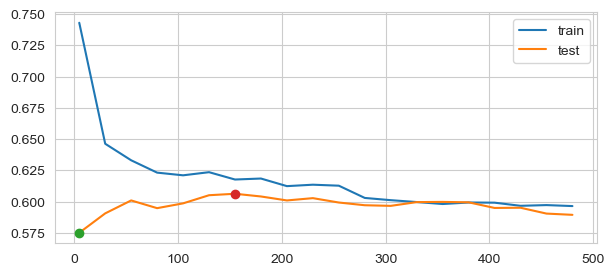

Дефолтный скор: 0.5752
Максимальный скор: 0.6063 при k = 155
Прирост скора: 0.0312


In [22]:
X = df.drop(columns = ['welding_mode'])
y = df['welding_mode']

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(25*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


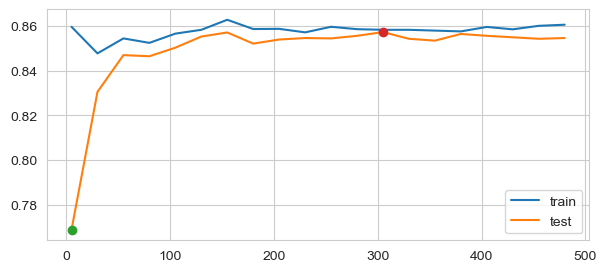

Дефолтный скор: 0.7687
Максимальный скор: 0.8573 при k = 305
Прирост скора: 0.0887


In [23]:
X = df.drop(columns = ['welding_mode'])
y = df['welding_mode']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(25*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

In [25]:
df = abs(df)
df

,weld_penetration_depth,seam_width,seam_height,welding_current,welding_voltage,welding_speed,wire_feed_speed,wire_diameter,gas_flow_rate,gas_pressure,...,controller_temp,cooling_water_temp,power_fluctuation,induction_noise,electrode_condition,contact_tip_wear,nozzle_soiling,weld_metal_type,batch_metal_quality,welding_mode
0,6.699538,9.678469,1.901264,181.701670,29.573171,10.575318,4.886314,1.135564,17.360429,5.590061,...,0.132031,0.986646,3.605200,57.431062,1.670170,162.482074,4.819398,3.597777,7.029275,0
1,6.903177,8.122463,1.724128,156.262807,29.847086,11.211411,6.159547,1.031911,12.331770,7.076134,...,0.074574,1.896970,2.764271,44.748190,1.196695,149.340482,5.899627,3.716755,5.829532,0
2,7.657659,11.920721,5.276859,221.024566,29.209548,10.566121,11.036719,1.104112,14.015379,8.141023,...,0.110405,2.438312,2.835237,59.283466,2.043028,168.572653,3.911573,6.617757,7.469624,1
3,5.671349,9.409989,0.874476,214.798158,19.409558,5.905609,7.967358,1.287985,17.454204,7.547302,...,0.267797,0.972218,2.668976,70.456453,1.473534,156.472188,2.401296,4.892282,5.080182,0
4,6.105178,12.856322,3.073883,170.634770,28.056183,15.149021,7.811477,1.342785,11.713977,6.105746,...,0.186530,2.223985,2.082497,32.346181,0.934839,138.616406,4.735667,7.238008,5.110356,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,7.245504,6.544657,2.093036,205.135113,27.654239,14.123206,6.068258,1.234679,15.910701,8.482377,...,0.185972,1.731587,3.255977,51.568997,2.000779,172.895595,3.455237,3.675372,5.795367,0
1996,3.739063,10.136176,2.228687,138.652159,22.642387,13.177423,7.259696,1.345563,10.607930,5.093761,...,0.099531,2.117045,1.787467,70.475634,1.406289,115.974520,4.449903,4.418312,2.471723,1
1997,6.360357,7.805790,2.744357,218.032631,18.877906,14.441496,6.394878,1.060920,15.002914,6.488252,...,0.399521,1.112311,3.116146,75.988122,0.846785,176.606832,6.559804,5.925830,6.657667,1
1998,7.186548,6.454041,3.823633,202.182631,29.751755,8.482869,8.627471,1.162448,18.540646,7.827164,...,0.235037,1.324541,3.102485,59.206069,0.787537,94.238300,4.340026,3.157663,5.170365,0


In [26]:
# df.to_csv('data/weld.csv', index = False)

In [27]:
df = pd.read_csv('data/weld.csv')
df

,weld_penetration_depth,seam_width,seam_height,welding_current,welding_voltage,welding_speed,wire_feed_speed,wire_diameter,gas_flow_rate,gas_pressure,...,controller_temp,cooling_water_temp,power_fluctuation,induction_noise,electrode_condition,contact_tip_wear,nozzle_soiling,weld_metal_type,batch_metal_quality,welding_mode
0,6.699538,9.678469,1.901264,181.701670,29.573171,10.575318,4.886314,1.135564,17.360429,5.590061,...,0.132031,0.986646,3.605200,57.431062,1.670170,162.482074,4.819398,3.597777,7.029275,0
1,6.903177,8.122463,1.724128,156.262807,29.847086,11.211411,6.159547,1.031911,12.331770,7.076134,...,0.074574,1.896970,2.764271,44.748190,1.196695,149.340482,5.899627,3.716755,5.829532,0
2,7.657659,11.920721,5.276859,221.024566,29.209548,10.566121,11.036719,1.104112,14.015379,8.141023,...,0.110405,2.438312,2.835237,59.283466,2.043028,168.572653,3.911573,6.617757,7.469624,1
3,5.671349,9.409989,0.874476,214.798158,19.409558,5.905609,7.967358,1.287985,17.454204,7.547302,...,0.267797,0.972218,2.668976,70.456453,1.473534,156.472188,2.401296,4.892282,5.080182,0
4,6.105178,12.856322,3.073883,170.634770,28.056183,15.149021,7.811477,1.342785,11.713977,6.105746,...,0.186530,2.223985,2.082497,32.346181,0.934839,138.616406,4.735667,7.238008,5.110356,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,7.245504,6.544657,2.093036,205.135113,27.654239,14.123206,6.068258,1.234679,15.910701,8.482377,...,0.185972,1.731587,3.255977,51.568997,2.000779,172.895595,3.455237,3.675372,5.795367,0
1996,3.739063,10.136176,2.228687,138.652159,22.642387,13.177423,7.259696,1.345563,10.607930,5.093761,...,0.099531,2.117045,1.787467,70.475634,1.406289,115.974520,4.449903,4.418312,2.471723,1
1997,6.360357,7.805790,2.744357,218.032631,18.877906,14.441496,6.394878,1.060920,15.002914,6.488252,...,0.399521,1.112311,3.116146,75.988122,0.846785,176.606832,6.559804,5.925830,6.657667,1
1998,7.186548,6.454041,3.823633,202.182631,29.751755,8.482869,8.627471,1.162448,18.540646,7.827164,...,0.235037,1.324541,3.102485,59.206069,0.787537,94.238300,4.340026,3.157663,5.170365,0


k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


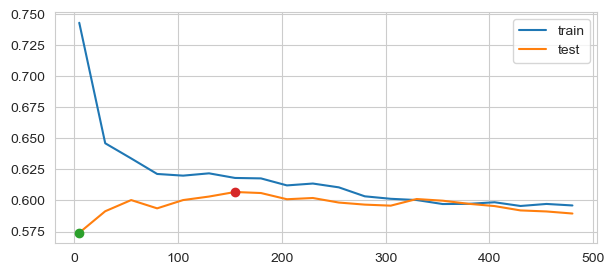

Дефолтный скор: 0.574
Максимальный скор: 0.6068 при k = 155
Прирост скора: 0.0328


In [28]:
X = df.drop(columns = ['welding_mode'])
y = df['welding_mode']

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(25*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


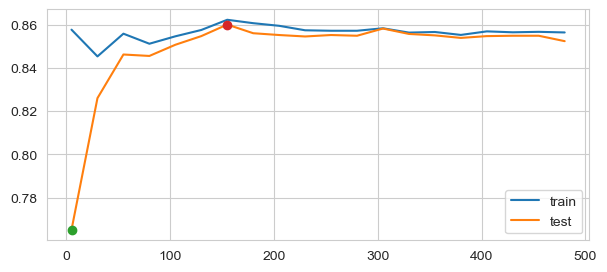

Дефолтный скор: 0.7652
Максимальный скор: 0.86 при k = 155
Прирост скора: 0.0948


In [29]:
X = df.drop(columns = ['welding_mode'])
y = df['welding_mode']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(25*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))